# BIRCH 算法实战：大规模图像数据压缩

本案例将演示如何使用 `BIRCH` (Balanced Iterative Reducing and Clustering using Hierarchies) 算法处理大规模数据集。BIRCH 的最大优势在于其**极高的内存效率**和**单次扫描**特性，这使得它非常适合作为大规模数据聚类的预处理步骤（例如：先用 BIRCH 将 10万个样本压缩成 1000 个微簇，再对这 1000 个微簇进行精细聚类）。

我们将使用一张包含数十万像素的图像，演示如何利用 BIRCH 进行色彩量化（Color Quantization），实现图像压缩。

## 1. 准备工作

首先，我们需要加载一张示例图片。为了方便演示，我们使用 `scikit-learn` 自带的 `china` 图片。

原始图像形状: (427, 640, 3)
扁平化后的数据形状: (273280, 3)


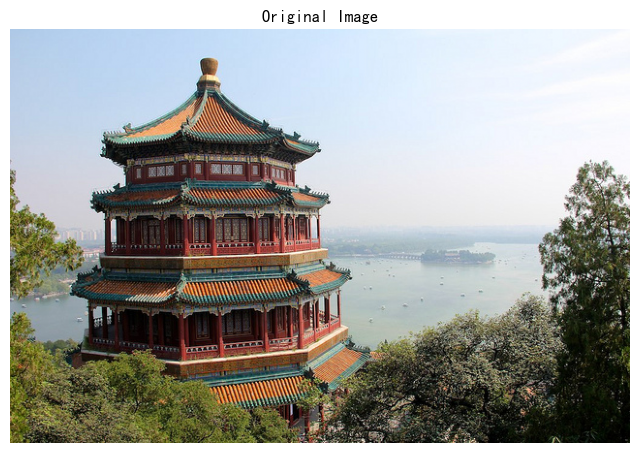

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from sklearn.utils import shuffle
from time import time

# 加载示例图像
china = load_sample_image("china.jpg")

# 归一化像素值到 0-1 之间
china = np.array(china, dtype=np.float64) / 255

# 获取图像尺寸
w, h, d = china.shape
original_shape = (w, h, d)
n_colors = 64 # 我们希望将成千上万种颜色压缩成 64 种主色调

# 将图像数据重塑为 (N_pixels, 3) 的二维数组
image_array = np.reshape(china, (w * h, d))

print(f"原始图像形状: {original_shape}")
print(f"扁平化后的数据形状: {image_array.shape}")

# 可视化原始图像
plt.figure(figsize=(8, 6))
plt.imshow(china)
plt.title("Original Image")
plt.axis('off')
plt.show()

## 2. 使用 BIRCH 算法进行聚类

我们将使用 BIRCH 算法对像素点的颜色进行聚类。这里的每个“簇”代表一种主色调。BIRCH 会构建一棵 CF 树，将相似的颜色聚合在一起。

**关键参数说明：**
- `threshold`: 决定了微簇（Subcluster）的半径阈值。阈值越小，生成的微簇越多，细节保留越好，但计算量增加。
- `branching_factor`: 决定了 CF 树每个节点的最大子节点数。影响树的宽度和深度。
- `n_clusters`: 最终希望得到的簇数量（这里是 64 种颜色）。

In [2]:
from sklearn.cluster import Birch

print(f"正在使用 BIRCH 算法对 {image_array.shape[0]} 个像素点进行聚类...")
t0 = time()

# 构建 BIRCH 模型
# threshold=0.05: 如果样本点与最近簇中心的距离小于 0.05，则加入该簇；否则创建新簇
birch_model = Birch(n_clusters=n_colors, threshold=0.05, branching_factor=50)

# 训练模型
birch_model.fit(image_array)

print(f"聚类完成，耗时: {time() - t0:.3f} 秒")

# 获取聚类中心（即 64 种主色调）
cluster_centers = birch_model.subcluster_centers_

# 注意：BIRCH 的 subcluster_centers_ 数量可能多于 n_clusters，
# 因为它在最后一步可能会使用 AgglomerativeClustering 对 subclusters 进行合并。
# 如果我们直接指定了 n_clusters=None，则需要手动处理 subcluster_centers_。
# 在 sklearn 的实现中，如果 n_clusters 设置为整数，fit 后我们可以通过 predict 获取标签。

# 预测每个像素点的颜色标签
labels = birch_model.predict(image_array)

# 此时的 cluster_centers 实际上应该是最终合并后的中心
# 但 Birch 对象的属性略有不同，我们可以通过计算每个簇的平均值来获取最终的 64 个中心颜色
final_centers = np.zeros((n_colors, 3))
for i in range(n_colors):
    final_centers[i] = np.mean(image_array[labels == i], axis=0)

正在使用 BIRCH 算法对 273280 个像素点进行聚类...
聚类完成，耗时: 4.087 秒


## 3. 重构并显示压缩后的图像

现在我们用聚类中心（主色调）替换原始像素值，重建图像。

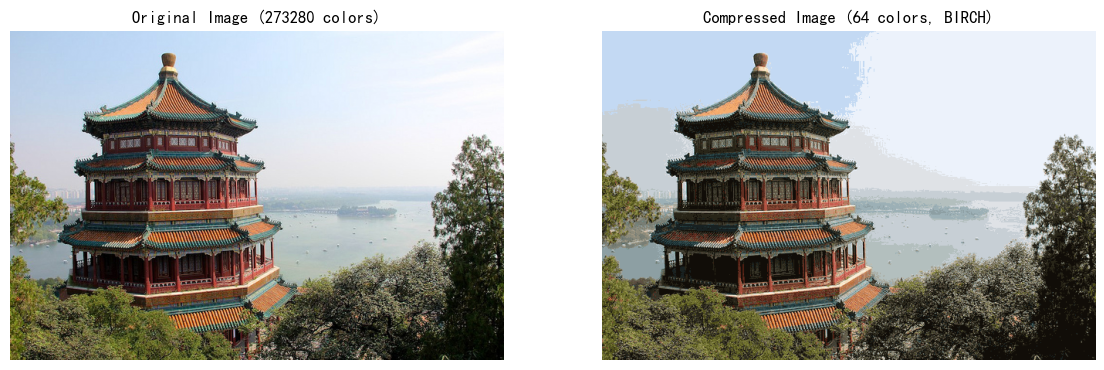

In [3]:
def recreate_image(codebook, labels, w, h):
    """使用聚类中心和标签重构图像"""
    d = codebook.shape[1]
    image = np.zeros((w, h, d))
    label_idx = 0
    for i in range(w):
        for j in range(h):
            image[i][j] = codebook[labels[label_idx]]
            label_idx += 1
    return image

# 重构图像
compressed_china = recreate_image(final_centers, labels, w, h)

# 可视化对比
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(china)
plt.title(f"Original Image ({w*h} colors)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(compressed_china)
plt.title(f"Compressed Image ({n_colors} colors, BIRCH)")
plt.axis('off')

plt.show()

## 4. 结论

通过本案例，我们可以看到 BIRCH 算法在处理数十万个数据点（像素）时的表现：

1.  **速度快**：相比于直接对所有像素运行 K-Means，BIRCH 通过构建 CF 树极大地加速了聚类过程。
2.  **压缩效果**：虽然只使用了 64 种颜色，但图像的主要结构和色彩特征得到了很好的保留。
3.  **内存友好**：BIRCH 不需要将所有数据点的距离矩阵加载到内存中，适合大规模数据处理。